In [1]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


N = 10000
w = 0.6

iterations = 50
s = 0.3
ks = [1, 3, 5, 7, 10]


cols = ['condition', 'cate', 'distance', 'T0', 'T1', 'depth', 'norm_cate',
       'score','algorithm', 'weight']

scores = pd.DataFrame(columns=cols)

for exp in tqdm(range(iterations)):
    data = Data()
    data.generate(n=N, seed=exp)
    data.generate_random_condition(selectivity_threshold=s)

    ct_D = CT(data, on = "D")
    ct_D.parse_tree()

    ct_P = CT(data, on = "P")
    ct_P.parse_tree()

    for K in ks:
        ct_D_scores = ct_D.get_topK(k=K, w=w, print_summaries=False)
        ct_D_scores['K'] = K
        scores=pd.concat([scores, ct_D_scores], ignore_index=True)

        ct_P_scores = ct_P.get_topK(k=K, w=w, print_summaries=False)
        ct_P_scores['K'] = K
        scores=pd.concat([scores, ct_P_scores], ignore_index=True)

100%|██████████| 50/50 [00:10<00:00,  4.90it/s]


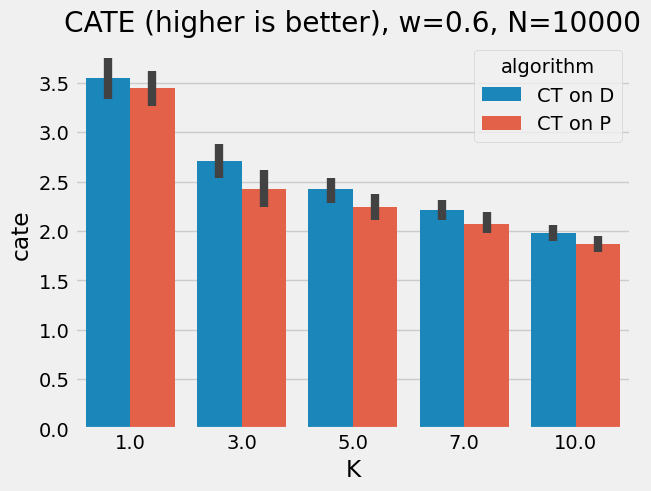

In [2]:
sns.barplot(x='K', y='cate', hue='algorithm', data=scores)
plt.title(f"CATE (higher is better), w={str(w)}, N={str(N)}")
plt.show()

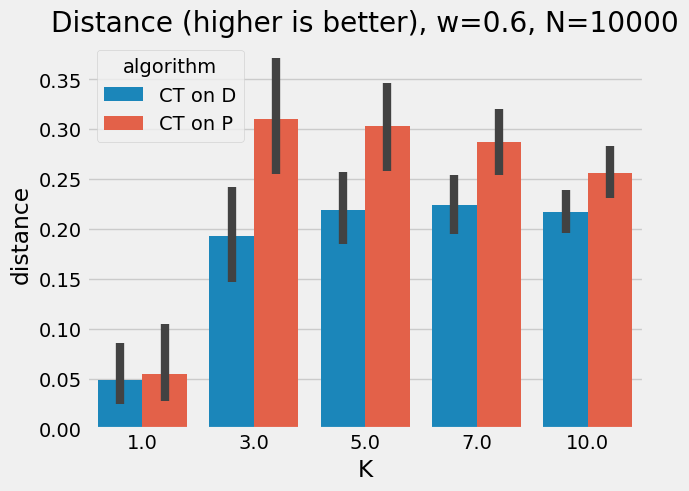

In [3]:
sns.barplot(x='K', y='distance', hue='algorithm', data=scores)
plt.title(f"Distance (higher is better), w={str(w)}, N={str(N)}")
plt.show()

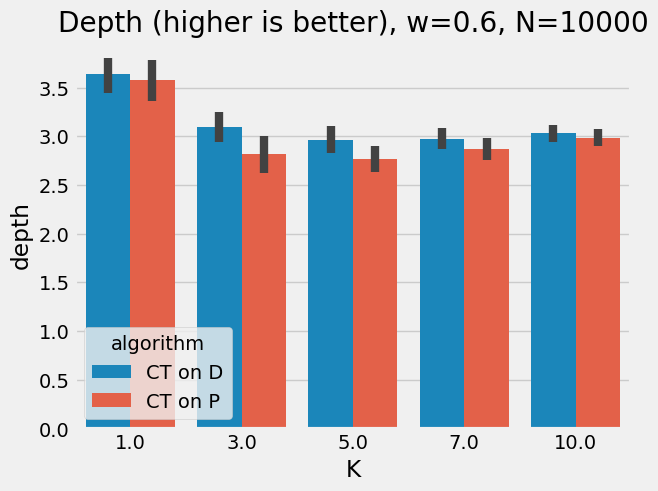

In [4]:
sns.barplot(x='K', y='depth', hue='algorithm', data=scores)
plt.title(f"Depth (higher is better), w={str(w)}, N={str(N)}")
plt.show()